In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv')

In [4]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [5]:
df.shape

(25000, 3)

In [6]:
df['Height(Inches)'].describe()

count    25000.000000
mean        67.993114
std          1.901679
min         60.278360
25%         66.704397
50%         67.995700
75%         69.272958
max         75.152800
Name: Height(Inches), dtype: float64

In [7]:
import seaborn as sns

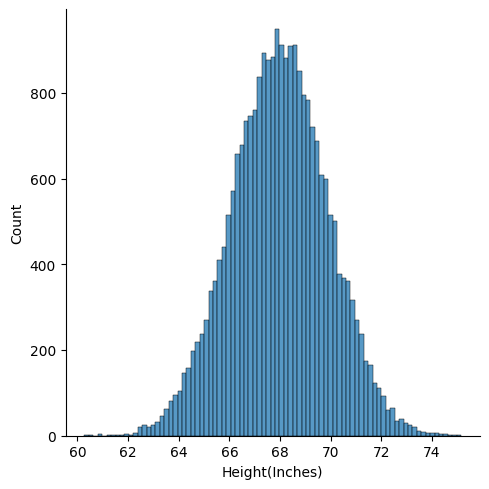

In [8]:
sns.displot(df['Height(Inches)'])

<Axes: ylabel='Height(Inches)'>

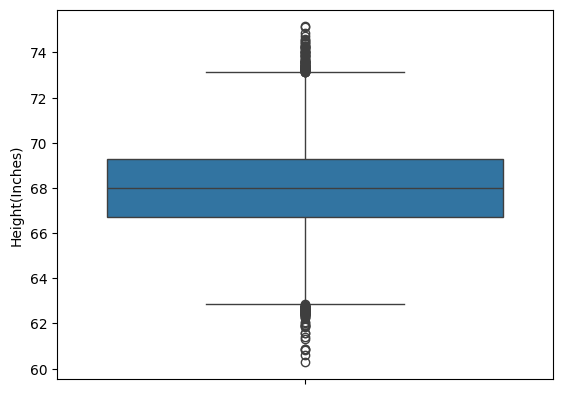

In [9]:
sns.boxplot(df['Height(Inches)'])

In [10]:
upper_limit = df['Height(Inches)'].quantile(0.99)
upper_limit

np.float64(72.37221499999998)

In [11]:
lower_limit = df['Height(Inches)'].quantile(0.01)
lower_limit

np.float64(63.5986493)

In [12]:
new_df = df[(df['Height(Inches)'] <= 72.59) & (df['Height(Inches)'] >= 63.60 )]

In [13]:
new_df['Height(Inches)'].describe()

count    24562.000000
mean        68.004332
std          1.791815
min         63.602550
25%         66.737510
50%         68.001075
75%         69.254245
max         72.588240
Name: Height(Inches), dtype: float64

In [14]:
df['Height(Inches)'].describe()

count    25000.000000
mean        67.993114
std          1.901679
min         60.278360
25%         66.704397
50%         67.995700
75%         69.272958
max         75.152800
Name: Height(Inches), dtype: float64

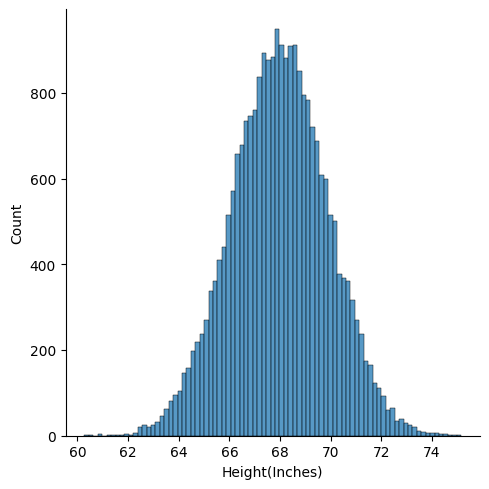

In [15]:
sns.displot(df['Height(Inches)'])

<Axes: ylabel='Height(Inches)'>

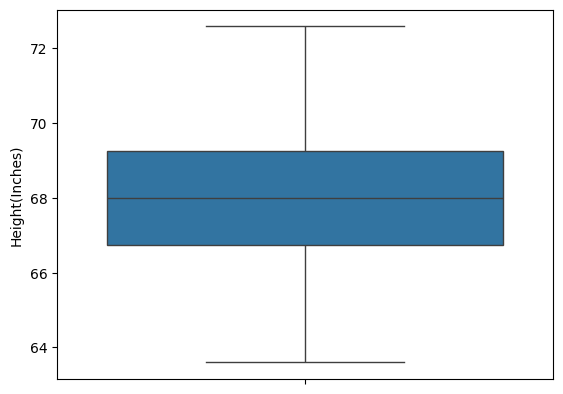

In [16]:
sns.boxplot(new_df['Height(Inches)'])

In [17]:
#capping --> Winsorization
df['Height(Inches)'] = np.where(df['Height(Inches)'] >= upper_limit,
        upper_limit,
        np.where(df['Height(Inches)'] <= lower_limit,
        lower_limit,
        df['Height(Inches)']))

In [18]:
df.shape

(25000, 3)

In [19]:
df['Height(Inches)'].describe()

count    25000.000000
mean        67.992508
std          1.868011
min         63.598649
25%         66.704397
50%         67.995700
75%         69.272958
max         72.372215
Name: Height(Inches), dtype: float64

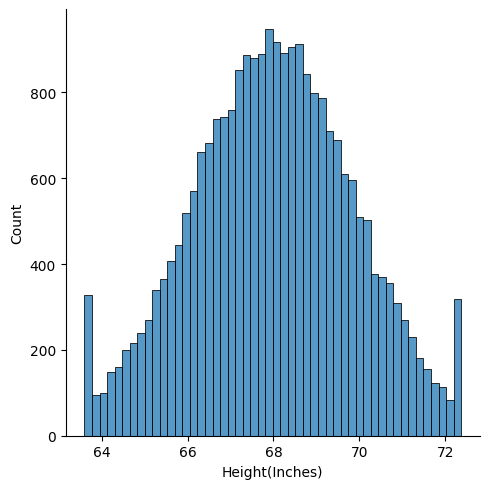

In [20]:
sns.displot(df['Height(Inches)'])

<Axes: ylabel='Height(Inches)'>

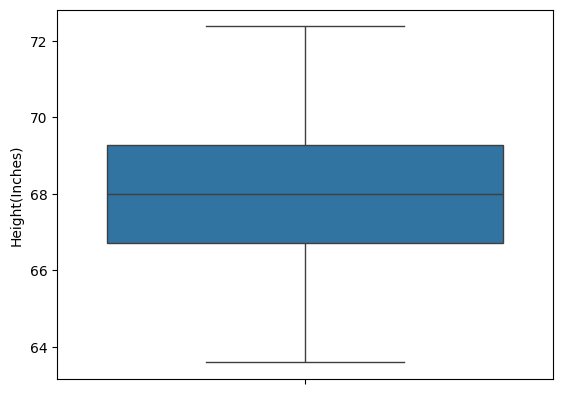

In [21]:
sns.boxplot(df['Height(Inches)'])